In [13]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [14]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [15]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Specfying the (initial) device and solver dimensions and params ##

In [16]:
# Function to generate aleatory values with a uniform distribution

import random

def aleatory_value(a, b, p = 2):
    factor = 10**p
    return random.randint(int(a*factor), int(b*factor)) / factor

### fixed params of the otimization ###

In [17]:
w1 = 0.5*um
w13 = 1.4*um
L = 2*um # Tamanho do corpo
H = 220*nm

n_sections = 12 # Número de divisões do corpo
n_particles = 50 # Número de particulas
w_matrix = np.zeros((n_particles, n_sections+1))
v_matrix = np.zeros((n_particles, n_sections+1))

for i in range(0, n_particles, 1):
    w_matrix[i, 0 ] = w1
    w_matrix[i, -1] = w13

dL = L/n_sections
L_rects = 10*dL

### FDTD dimensions and parameters ###

In [ ]:
#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#FDTD:

x_span_fdtd = L + 1.5*L_rects
y_span_fdtd = 3*um
z_span_fdtd = 3*H
simulation_time = 20*x_span_fdtd/c

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy_2D = 5
mesh_accuracy_3D = 7

indxLambda = 24

### conditions for the otimization ###

In [25]:
#constants of the PSO algorithm:

c1 = 1.6
c2 = 2.00
omega_max = 0.9
omega_min = 0.4
N_iterations = 15
N_iterations_3D = 30
N_iterations_3D_2 = 15
dt = 1

#initial values:

w_min_initial = 0.7 * um
w_max_initial = 1.8 * um

v_max_amplitude = 0.1 * um

for i in range(0, n_particles, 1):
    for j in range(1, n_sections, 1):
        w_matrix[i, j] = aleatory_value(w_min_initial, w_max_initial, p = 8)
        v_matrix[i, j] = aleatory_value(-v_max_amplitude, v_max_amplitude, p = 8)

## Building the simulation region ##

In [20]:
fdtdApi.addfdtd()
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('dimension', '2D')
fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy_2D)
fdtdApi.set('simulation time', simulation_time)

# add ports 
fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -L/2 - L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', 0)
fdtdApi.set('y span', w_matrix[-1, -1] - 0.6*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', L/2 + dL/2+ L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', (w_matrix[-1, -1] - w_matrix[0, 0])/2)
fdtdApi.set('y span', w_matrix[-1, -1] - 0.6*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'port_3')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', L/2 + dL/2 + L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', -(w_matrix[-1, -1] - w_matrix[0, 0])/2)
fdtdApi.set('y span', w_matrix[-1, -1] - 0.6*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

# add monitors

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)

fdtdApi.save('Y-branch PSO otimization')

# Starting the otimization #

### 2D otimization ###

In [21]:
p_best_matrix = w_matrix.copy()
T_best_array = np.ones(n_particles)
g_best_array = w_matrix[0].copy()
G_best = 1

from scipy.interpolate import CubicSpline

In [ ]:
# building the device:

W_array = w_matrix[0].copy()

## Spline interpolation

y_max_array = W_array/2
x_original = np.arange(-L/2, L/2, dL)
cs = CubicSpline(x_original, y_max_array)
coeficients = cs.c
coeficients[0,:] = coeficients[0,:]*um**2
coeficients[1,:] = coeficients[1,:]*um
coeficients[2,:] = coeficients[2,:]
coeficients[3,:] = coeficients[3,:]/um

## building the device:

fdtdApi.addrect()
fdtdApi.set('name', 'poly_0')
fdtdApi.set('material', material)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('x', -L/2 + dL/2)
fdtdApi.set('x span', dL)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[0])
fdtdApi.addtogroup('group')


for i in range(1, len(W_array), 1):
    fdtdApi.addpoly()
    fdtdApi.set('name', 'poly_%d' %i)
    fdtdApi.set('material', material)
    fdtdApi.set('z', 0)
    fdtdApi.set('z span', H)

    xi = (-L/2 + i*dL)/um
    x = np.linspace(xi, xi + dL/um, 21)
    y = coeficients[0,i-1]*(x-xi)**3 + coeficients[1,i-1]*(x-xi)**2 + coeficients[2,i-1]*(x-xi) + coeficients[3,i-1]
    x_block = np.concatenate((x, np.flip(x)))*um
    y_block = np.concatenate((y, -np.flip(y)))*um
    vertices = np.block([[x_block[i], y_block[i]] for i in range(len(x_block))])
    fdtdApi.set('vertices', vertices)
    x += dL
    fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect')
fdtdApi.set('material', material)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('x', L/2 + dL/2)
fdtdApi.set('x span', dL)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[-1])
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_0')
fdtdApi.set('x', -(L+dL)/2)
fdtdApi.set('x span', dL)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_1')
fdtdApi.set('x', -L/2 - dL - L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_2')
fdtdApi.set('x', L/2+ dL + L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', (w_matrix[-1, -1] - w_matrix[0, 0])/2)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_3')
fdtdApi.set('x', L/2+ dL + L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', -(w_matrix[-1, -1] - w_matrix[0, 0])/2)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

In [23]:
from IPython.display import clear_output

omega = omega_max

for n in range(0, N_iterations, 1):

    clear_output()
    print('Iteration %d/%d' %(n+1, N_iterations))

    for i in range(0, n_particles, 1):
        fdtdApi.switchtolayout()

        # building the device:

        W_array = w_matrix[i].copy()

        ## Spline interpolation

        y_max_array = W_array/2
        x_original = np.arange(-L/2, L/2+dL, dL)
        cs = CubicSpline(x_original, y_max_array)
        coeficients = cs.c
        coeficients[0,:] = coeficients[0,:]*um**2
        coeficients[1,:] = coeficients[1,:]*um
        coeficients[2,:] = coeficients[2,:]
        coeficients[3,:] = coeficients[3,:]/um

        ## building the device:

        for j in range(1, len(W_array), 1):
            fdtdApi.select('group::poly_%d' %j)

            xi = (-L/2 + j*dL)/um
            x = np.linspace(xi, xi + dL/um, 21)
            y = coeficients[0,j-1]*(x-xi)**3 + coeficients[1,j-1]*(x-xi)**2 + coeficients[2,j-1]*(x-xi) + coeficients[3,j-1]
            x_block = np.round(np.concatenate((x, np.flip(x)))*um, 8)
            y_block = np.round(np.concatenate((y, -np.flip(y)))*um, 8)
            vertices = np.block([[x_block[k], y_block[k]] for k in range(len(x_block))])
            fdtdApi.set('vertices', vertices)

        # running a simulation

        fdtdApi.run()

        T = fdtdApi.getresult('FDTD::ports::port_2', 'T')
        T = np.abs(T['T'])[indxLambda]

        if np.abs(0.5 - T) < np.abs(0.5 - T_best_array[i]):
            T_best_array[i] = T
            p_best_matrix[i] = w_matrix[i].copy()

    if np.min(np.abs(0.5 - T_best_array)) < np.abs(0.5-G_best):
        G_best = T_best_array[np.argmin(np.abs(0.5 - T_best_array))]
        g_best_array = p_best_matrix[np.argmin(np.abs(0.5 - T_best_array))]

    for i in range(0, n_particles, 1):
        for j in range(1, n_sections, 1):
            v_matrix[i, j] = round(omega * v_matrix[i, j] + c1 * np.random.rand() * (p_best_matrix[i, j] - w_matrix[i, j]) + c2 * np.random.rand() * (g_best_array[j] - w_matrix[i, j]), 9)
            v_matrix[i, j] = np.clip(v_matrix[i, j], -v_max_amplitude, v_max_amplitude)
            w_matrix[i, j] = w_matrix[i, j] + v_matrix[i, j]*dt
            w_matrix[i, j] = np.clip(w_matrix[i, j], 0.5*um, y_span_fdtd)

    omega -= (omega_max - omega_min)/(N_iterations-1)        

Iteration 15/15


### 3D otimization ###

In [ ]:
fdtdApi.switchtolayout()
fdtdApi.setnamed('FDTD', 'dimension', '3D')
fdtdApi.setnamed('FDTD', 'mesh accuracy', mesh_accuracy_3D)
fdtdApi.setnamed('FDTD', 'z min bc', 'Symmetric')

c1 = 1.5
omega_min = 0.35

omega = omega_max

p_best_matrix_3D = w_matrix.copy()
T_best_array_3D = np.ones(n_particles)
g_best_array_3D = g_best_array.copy()
G_best_3D = 1

for i in range(0, n_particles, 1):
    for j in range(1, n_sections, 1):
        v_matrix[i, j] = aleatory_value(-v_max_amplitude, v_max_amplitude, p = 8)

for n in range(0, N_iterations_3D, 1):

    clear_output()
    print('Iteration %d/%d' %(n+1, N_iterations_3D))

    for i in range(0, n_particles, 1):
        fdtdApi.switchtolayout()

        # building the device:

        W_array = w_matrix[i].copy()

        ## Spline interpolation

        y_max_array = W_array/2
        x_original = np.arange(-L/2, L/2+dL, dL)
        cs = CubicSpline(x_original, y_max_array)
        coeficients = cs.c
        coeficients[0,:] = coeficients[0,:]*um**2
        coeficients[1,:] = coeficients[1,:]*um
        coeficients[2,:] = coeficients[2,:]
        coeficients[3,:] = coeficients[3,:]/um

        ## building the device:


        for j in range(1, len(W_array), 1):
            fdtdApi.select('group::poly_%d' %j)

            xi = (-L/2 + j*dL)/um
            x = np.linspace(xi, xi + dL/um, 21)
            y = coeficients[0,j-1]*(x-xi)**3 + coeficients[1,j-1]*(x-xi)**2 + coeficients[2,j-1]*(x-xi) + coeficients[3,j-1]
            x_block = np.round(np.concatenate((x, np.flip(x)))*um, 8)
            y_block = np.round(np.concatenate((y, -np.flip(y)))*um, 8)
            vertices = np.block([[x_block[k], y_block[k]] for k in range(len(x_block))])
            fdtdApi.set('vertices', vertices)

        # running a simulation

        fdtdApi.run()

        T = fdtdApi.getresult('FDTD::ports::port_2', 'T')
        T = np.abs(T['T'])[indxLambda]

        if np.abs(0.5 - T) < np.abs(0.5 - T_best_array_3D[i]):
            T_best_array_3D[i] = T
            p_best_matrix_3D[i] = w_matrix[i].copy()

    if np.min(np.abs(0.5 - T_best_array_3D)) < np.abs(0.5-G_best_3D):
        G_best_3D = T_best_array_3D[np.argmin(np.abs(0.5 - T_best_array_3D))]
        g_best_array_3D = p_best_matrix_3D[np.argmin(np.abs(0.5 - T_best_array_3D))]

    for i in range(0, n_particles, 1):
        for j in range(1, n_sections, 1):
            v_matrix[i, j] = round(omega * v_matrix[i, j] + c1 * np.random.rand() * (p_best_matrix_3D[i, j] - w_matrix[i, j]) + c2 * np.random.rand() * (g_best_array_3D[j] - w_matrix[i, j]), 9)
            v_matrix[i, j] = np.clip(v_matrix[i, j], -v_max_amplitude, v_max_amplitude)
            w_matrix[i, j] = w_matrix[i, j] + v_matrix[i, j]*dt
            w_matrix[i, j] = np.clip(w_matrix[i, j], 0.5*um, y_span_fdtd)

    omega -= (omega_max - omega_min)/(N_iterations_3D-1)
        

Iteration 1/30


LumApiError: "Can not find result 'T' in the result provider 'FDTD::ports::port_2'"

In [ ]:
fdtdApi.switchtolayout()

c1 = 1.5
omega_min = 0.3

omega = omega_max

for i in range(0, n_particles, 1):
    for j in range(1, n_sections, 1):
        v_matrix[i, j] = aleatory_value(-v_max_amplitude, v_max_amplitude, p = 8)

for n in range(0, N_iterations_3D_2, 1):

    clear_output()
    print('Iteration %d/%d' %(n+1, N_iterations_3D_2))

    for i in range(0, n_particles, 1):
        fdtdApi.switchtolayout()

        # building the device:

        W_array = w_matrix[i].copy()

        ## Spline interpolation

        y_max_array = W_array/2
        x_original = np.arange(-L/2, L/2+dL, dL)
        cs = CubicSpline(x_original, y_max_array)
        coeficients = cs.c
        coeficients[0,:] = coeficients[0,:]*um**2
        coeficients[1,:] = coeficients[1,:]*um
        coeficients[2,:] = coeficients[2,:]
        coeficients[3,:] = coeficients[3,:]/um

        ## building the device:


        for j in range(1, len(W_array), 1):
            fdtdApi.select('group::poly_%d' %j)

            xi = (-L/2 + j*dL)/um
            x = np.linspace(xi, xi + dL/um, 21)
            y = coeficients[0,j-1]*(x-xi)**3 + coeficients[1,j-1]*(x-xi)**2 + coeficients[2,j-1]*(x-xi) + coeficients[3,j-1]
            x_block = np.round(np.concatenate((x, np.flip(x)))*um, 8)
            y_block = np.round(np.concatenate((y, -np.flip(y)))*um, 8)
            vertices = np.block([[x_block[k], y_block[k]] for k in range(len(x_block))])
            fdtdApi.set('vertices', vertices)

        # running a simulation

        fdtdApi.run()

        T = fdtdApi.getresult('FDTD::ports::port_2', 'T')
        T = np.abs(T['T'])[indxLambda]

        if np.abs(0.5 - T) < np.abs(0.5 - T_best_array_3D[i]):
            T_best_array_3D[i] = T
            p_best_matrix_3D[i] = w_matrix[i].copy()

    if np.min(np.abs(0.5 - T_best_array_3D)) < np.abs(0.5-G_best_3D):
        G_best_3D = T_best_array_3D[np.argmin(np.abs(0.5 - T_best_array_3D))]
        g_best_array_3D = p_best_matrix_3D[np.argmin(np.abs(0.5 - T_best_array_3D))]

    for i in range(0, n_particles, 1):
        for j in range(1, n_sections, 1):
            v_matrix[i, j] = round(omega * v_matrix[i, j] + c1 * np.random.rand() * (p_best_matrix_3D[i, j] - w_matrix[i, j]) + c2 * np.random.rand() * (g_best_array_3D[j] - w_matrix[i, j]), 9)
            v_matrix[i, j] = np.clip(v_matrix[i, j], -v_max_amplitude, v_max_amplitude)
            w_matrix[i, j] = w_matrix[i, j] + v_matrix[i, j]*dt
            w_matrix[i, j] = np.clip(w_matrix[i, j], 0.5*um, y_span_fdtd)

    omega -= (omega_max - omega_min)/(N_iterations_3D_2-1)

Iteration 10/10


## Visualizing the best geometry ##

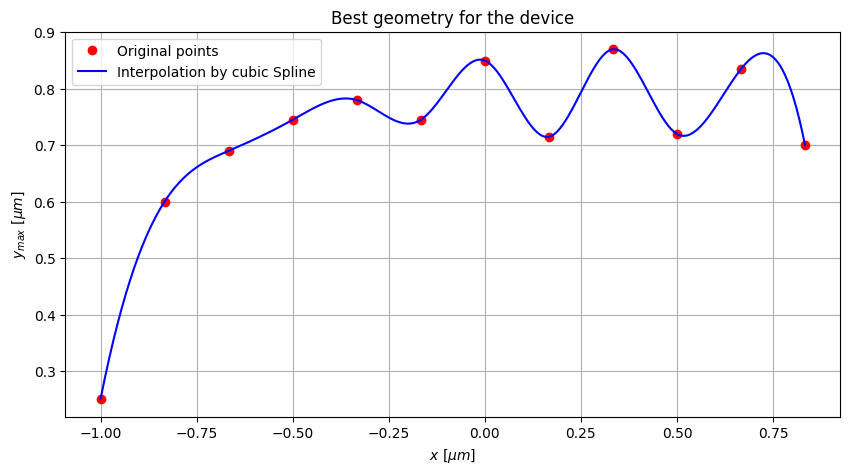

The transmission of this geometry, in percentage, is 45.58 (mesh 6)


In [ ]:
y_max_array = np.round(g_best_array_3D, 8)/2

x_original = np.arange(-L/2, L/2+dL, dL)

cs = CubicSpline(x_original, y_max_array)

x_soft = np.linspace(-L/2, x_original[-1], 501)
y_soft = cs(x_soft)

plt.figure(figsize=(10, 5))
plt.plot(x_original/um, y_max_array/um, 'o', color='red', label='Original points')
plt.plot(x_soft/um, y_soft/um, '-', color='blue', label='Interpolation by cubic Spline')
plt.title('Best geometry for the device')
plt.xlabel(r'$x\,\,[\mu m]$')
plt.ylabel(r'$y_{max}\,\,[\mu m]$')
plt.legend()
plt.grid(True)
plt.show()
#print('The transmission of this geometry, in percentage, is %.2f (mesh %d)' %(G_best_3D*100, mesh_accuracy_3D))

In [ ]:
np.savetxt('3D_parameters.txt', g_best_array_3D)

### analyzing the device's behavior  ###

In [ ]:
fdtdApi.switchtolayout()
fdtdApi.set('Mesh accuracy', 8)

W_array = g_best_array_3D.copy()

## Spline interpolation

y_max_array = W_array/2
x_original = np.arange(-L/2, L/2+dL, dL)
cs = CubicSpline(x_original, y_max_array)
coeficients = cs.c
coeficients[0,:] = coeficients[0,:]*um**2
coeficients[1,:] = coeficients[1,:]*um
coeficients[2,:] = coeficients[2,:]
coeficients[3,:] = coeficients[3,:]/um

for j in range(1, len(W_array), 1):
    fdtdApi.select('group::poly_%d' %j)

    xi = (-L/2 + j*dL)/um
    x = np.linspace(xi, xi + dL/um, 501)
    y = coeficients[0,j-1]*(x-xi)**3 + coeficients[1,j-1]*(x-xi)**2 + coeficients[2,j-1]*(x-xi) + coeficients[3,j-1]
    x_block = np.round(np.concatenate((x, np.flip(x)))*um, 8)
    y_block = np.round(np.concatenate((y, -np.flip(y)))*um, 8)
    vertices = np.block([[x_block[k], y_block[k]] for k in range(len(x_block))])
    fdtdApi.set('vertices', vertices)


In [ ]:
fdtdApi.run()

In [ ]:
index_x = np.squeeze(fdtdApi.getdata('index', 'index_x').real)
x_device = np.squeeze(fdtdApi.getdata('index', 'x'))/um
y_device = np.squeeze(fdtdApi.getdata('index', 'y'))/um

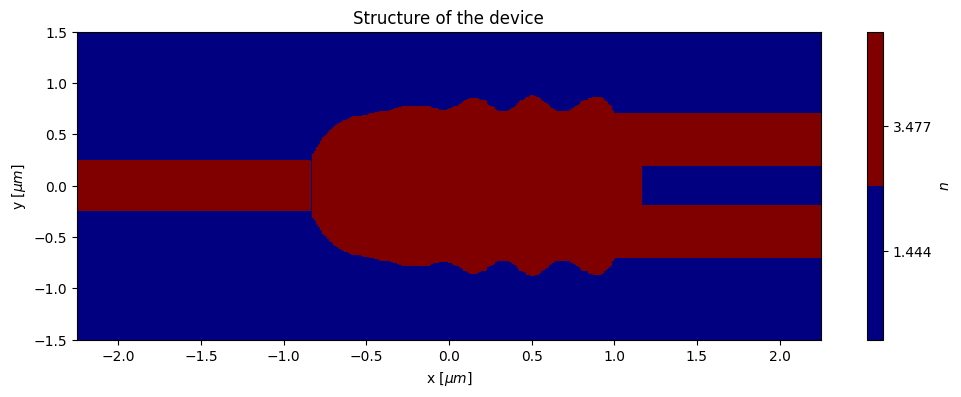

Device dimensions: 
w1 = 0.50 um
w2 = 1.20 um
w3 = 1.38 um
w4 = 1.49 um
w5 = 1.56 um
w6 = 1.49 um
w7 = 1.70 um
w8 = 1.43 um
w9 = 1.74 um
w10 = 1.44 um
w11 = 1.67 um
w12 = 1.40 um


In [ ]:
X, Y = np.meshgrid(x_device, y_device)
X, Y = np.transpose(X), np.transpose(Y)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

fig0 = plt.figure(figsize=(12,4))
im0 = plt.contourf(X, Y, index_x, 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im0, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Structure of the device')

plt.show()

print('Device dimensions: ')
for i in range(1, len(g_best_array_3D)+1, 1):
    print('w%d = %.2f um' %(i, g_best_array_3D[i-1]/um))

In [ ]:
eField_x = np.squeeze(fdtdApi.getdata('profile_xy', 'Ex'))
eField_y = np.squeeze(fdtdApi.getdata('profile_xy', 'Ey'))
eField_z = np.squeeze(fdtdApi.getdata('profile_xy', 'Ez'))

eField_abs2 = np.abs(eField_x)**2 + np.abs(eField_y)**2 + np.abs(eField_z)**2
eField_abs = np.sqrt(eField_abs2)

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

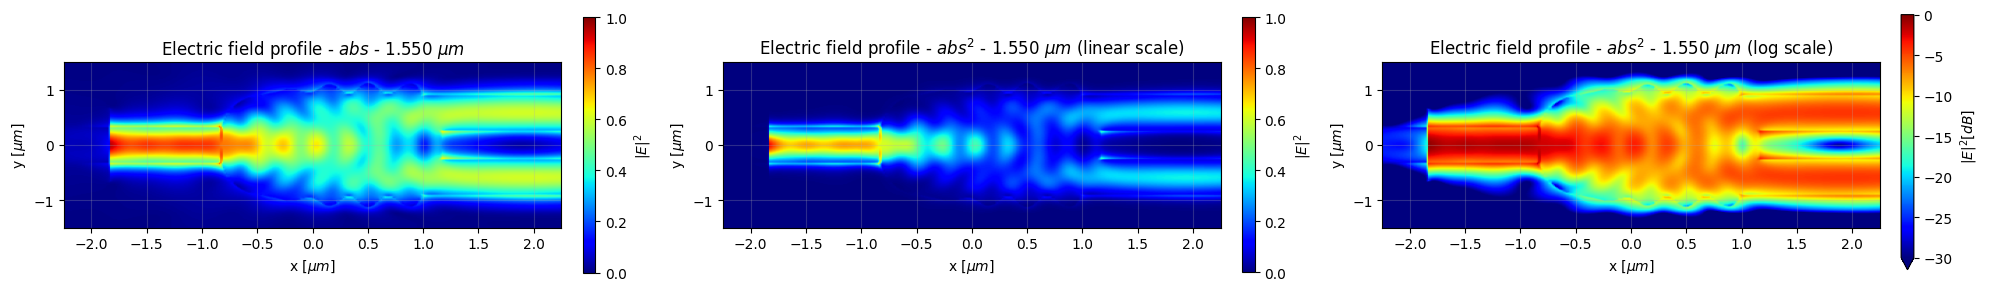

In [ ]:
fig1, ax1 = plt.subplots(1,3,figsize=(20,4))

im1 = ax1[0].imshow(np.rot90(eField_abs[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 0.5)
#ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.024, pad =0.04, label = r'$|E|^2$')

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - $abs$ - %4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(eField_abs2[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 0.5)

colorbar = plt.colorbar(im2,fraction = 0.024, pad =0.04, label = r'$|E|^2$')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

im3 = ax1[2].imshow(np.rot90(10*np.log10(eField_abs2[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 0.5)

colorbar = plt.colorbar(im3, fraction = 0.024, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[2].set_xlabel(r'x [$\mu m$]')
ax1[2].set_ylabel(r'y [$\mu m$]')
ax1[2].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[2].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

In [ ]:
T_port = np.zeros((3, number_of_frequency_points))
ports_lambda = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']/um

for i in range(1,4,1):
    port = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    T_port[i-1, :] = np.abs(port['T'])

In [ ]:
ports_lambda = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']/um

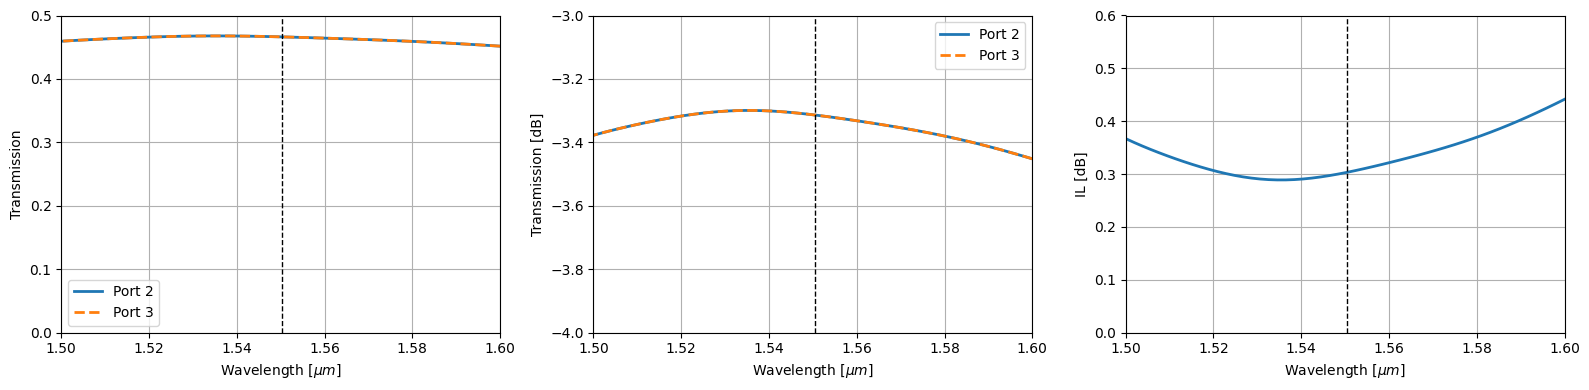

The transmission in each port in the central wavelength is 46.63% (-3.31 dB)
The Insertion Loss of the device is 0.30 dB


In [ ]:
fig2, ax2 = plt.subplots(1,3,figsize=(16,4))
for i in range(2,4,1):
    linestyle = '-'
    if i == 3:
        linestyle = '--'
    ax2[0].plot(ports_lambda, T_port[i-1,:]/T_port[0,:], label = 'Port %d' %i, linewidth = 2, linestyle = linestyle)

    T_dB_port = 10*(np.log10(T_port[i-1,:]) - np.log10(T_port[0,:]))
    ax2[1].plot(ports_lambda, T_dB_port, label = 'Port %d' %i, linewidth = 2, linestyle = linestyle)

ax2[0].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[0].set_xlabel(r'Wavelength [$\mu m$]')
ax2[0].set_ylabel(r'Transmission')
ax2[0].set_xlim([start_wavelength/um, stop_wavelength/um])
#ax2[0].set_ylim([0,1.1])
ax2[0].set_ylim([0,0.5])
ax2[0].grid(True)
ax2[0].legend(loc = 'best')

ax2[1].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[1].set_xlabel(r'Wavelength [$\mu m$]')
ax2[1].set_ylabel(r'Transmission [dB]')
ax2[1].set_xlim([start_wavelength/um, stop_wavelength/um])
ax2[1].set_ylim([-4,-3])
ax2[1].grid(True)
ax2[1].legend(loc = 'best')

insertion_Loss = 10*np.log10(T_port[0,:]) - 10*(np.log10(T_port[1,:] + T_port[2,:]))

ax2[2].plot(ports_lambda, insertion_Loss, linewidth = 2)
ax2[2].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[2].set_xlabel(r'Wavelength [$\mu m$]')
ax2[2].set_ylabel(r'IL [dB]')
ax2[2].set_xlim([start_wavelength/um, stop_wavelength/um])
ax2[2].set_ylim([0,0.6])
ax2[2].grid(True)

plt.tight_layout()
plt.show()

T_dB_port_2 = 10*(np.log10(T_port[1,:]) - np.log10(T_port[0,:]))


print('The transmission in each port in the central wavelength is %.2f%% (%.2f dB)' %(T_port[1, indxLambda]/T_port[0, indxLambda]*100, T_dB_port_2[indxLambda]))
print('The Insertion Loss of the device is %.2f dB' %(insertion_Loss[indxLambda]))

In [ ]:
fdtdApi.close()